In [4]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

In [5]:
df = pd.read_csv("SAMPL5.csv")

mols_to_select = [
    "SAMPL5_019",
    "SAMPL5_020",
    "SAMPL5_021",
    "SAMPL5_046",
    "SAMPL5_058",
    "SAMPL5_068",
    "SAMPL5_071",
    "SAMPL5_080",
    "SAMPL5_090",
]
df_selected = pd.DataFrame({"Molecule ID": mols_to_select}).merge(df, on="Molecule ID", how="left")
df_selected.drop(columns=["eMolecules ID"], inplace=True)
df_selected.to_csv("SAMPL5_selected.csv", index=False)
df_selected

,Molecule ID,SMILES
0,SAMPL5_019,Cc1ccc(cc1)Nc2ccnc(n2)Nc3ccc(cc3)C
1,SAMPL5_020,CCCC(=O)Nc1nc2ccc(cc2s1)C(C)C
2,SAMPL5_021,Cc1nn2cc(nc2s1)c3cccc(c3)OC
3,SAMPL5_046,CSc1ccc(cc1)CC(=O)Nc2c3ccsc3ncn2
4,SAMPL5_058,c1ccc(cc1)n2c(=O)c3ccccc3cn2
5,SAMPL5_068,c1ccc(cc1)c2c(nnc(n2)c3ccccn3)c4ccccc4
6,SAMPL5_071,CCOc1cc(c(cc1N2CCOCC2)OCC)N
7,SAMPL5_080,Cn1cnc2c1c(=O)n(c(=O)n2C)C
8,SAMPL5_090,Cc1cc2c(cc1C)nc(c(n2)c3ccccn3)c4ccccn4


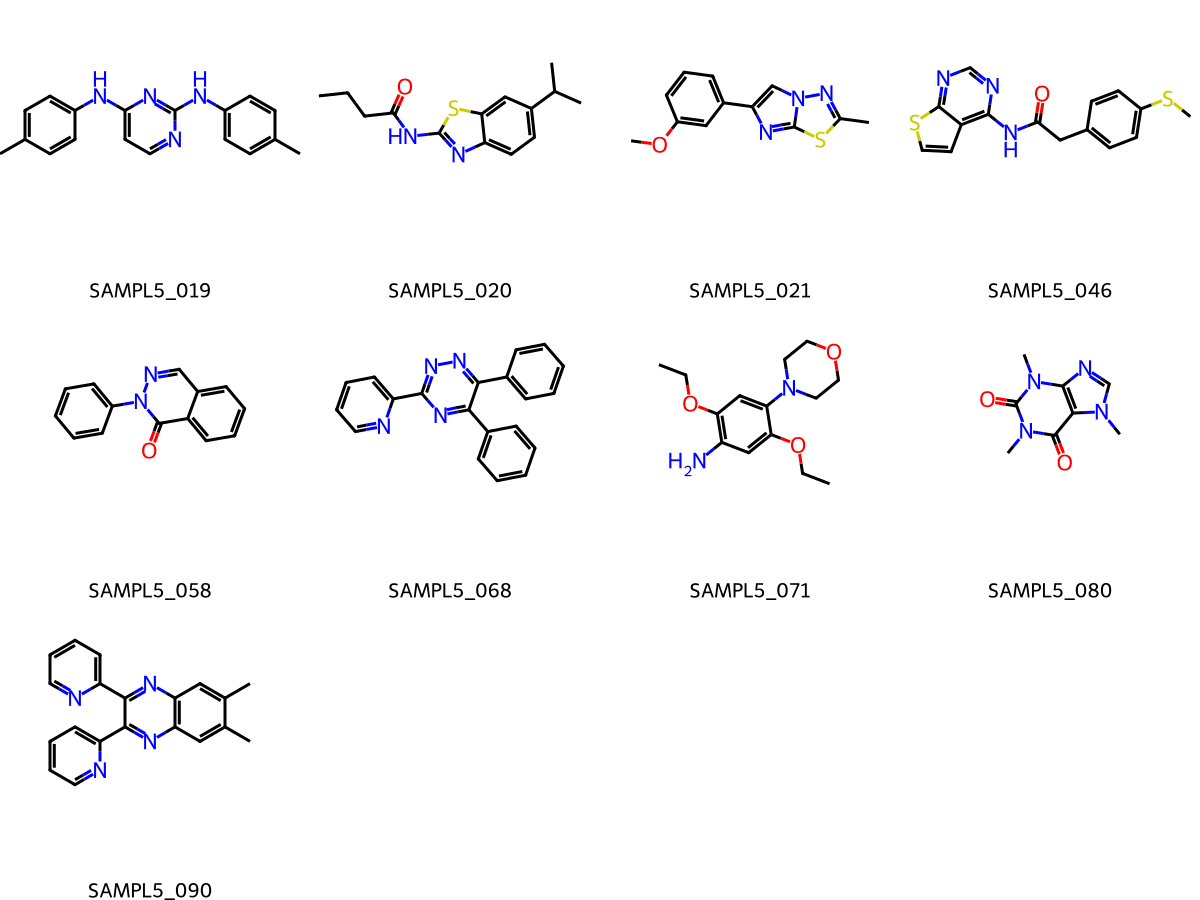

In [6]:
smiles_list = df_selected["SMILES"].tolist()
names_list = df_selected["Molecule ID"].tolist()

molecules = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]
draw_options = rdMolDraw2D.MolDrawOptions()
draw_options.explicitMethyl = False
draw_options.bondLineWidth = 3
draw_options.fixedFontSize = 22
draw_options.legendFontSize = 20
draw_options.legendFraction = 0.25
draw_options.padding = 0.0  # Reduce molecule padding inside each cell

svg = Draw.MolsToGridImage(
    molecules,
    molsPerRow=4,
    subImgSize=(300, 300),
    legends=names_list,
    useSVG=True,
    drawOptions=draw_options,
)

with open("molecules_grid.svg", "w") as f:
    f.write(svg.data)

svg